In [1]:
# Import Needed Libraries
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

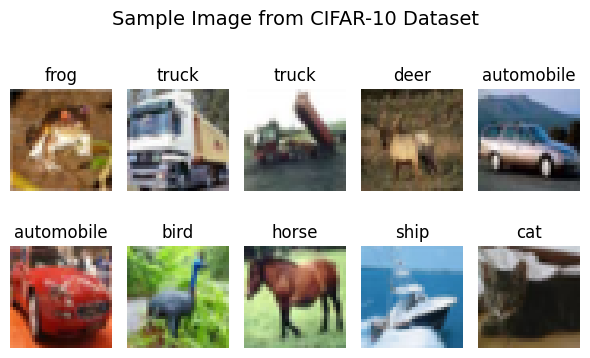

In [3]:
# Load CIFAR-10 Training set (we'll reuse this later too)
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Get class names
class_names = train_dataset.classes

# Plot some random images
fig, axes = plt.subplots(2, 5, figsize=(6, 4))
for i in range(10):
    image, label = train_dataset[i]
    ax = axes[i//5, i%5]
    ax.imshow(image.permute(1, 2, 0))   #convert CHW to HWC
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle("Sample Image from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
from collections import Counter

{'frog': 5000, 'truck': 5000, 'deer': 5000, 'automobile': 5000, 'bird': 5000, 'horse': 5000, 'ship': 5000, 'cat': 5000, 'dog': 5000, 'airplane': 5000}


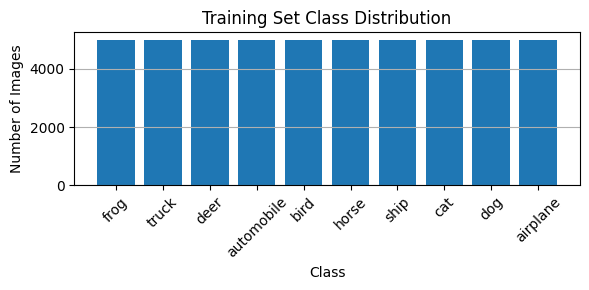

In [6]:
from collections import Counter

# Extract labels from the dataset
labels = [label for _, label in train_dataset]

# Count occurrences of each class
class_counts = Counter(labels)

# Convert to class name keys
class_counts_named = {class_names[k]: v for k, v in class_counts.items()}
print(class_counts_named)

# Plot
plt.figure(figsize=(6, 3))
plt.bar(class_counts_named.keys(), class_counts_named.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [7]:
from collections import Counter

# Step 1: Extract labels from train_dataset
CT_labels = []
for _, label in train_dataset:
    CT_labels.append(label)

# Step 2: Count occurrences of each label
CT_class_counts = Counter(labels)

# Step 3: Map indices to class names
CT_class_counts_named = {}
for idx, count in CT_class_counts.items():
    CT_class_counts_named[class_names[idx]] = count

# Step 4: Print counts
print("CT_class_counts:")
for name, count in CT_class_counts_named.items():
    print(f"{name}: {count}")



CT_class_counts:
frog: 5000
truck: 5000
deer: 5000
automobile: 5000
bird: 5000
horse: 5000
ship: 5000
cat: 5000
dog: 5000
airplane: 5000


In [8]:
# Get One Image and its Label
image, label = train_dataset[0]

print(f"Image tensor shape: {image.shape}")
print(f"Class Index: {label}")
print(f"Class name: {class_names[label]}")
print(f"Min pixel value: {image.min():.4f}")
print(f"Max pixel value: {image.max():.4f}")

Image tensor shape: torch.Size([3, 32, 32])
Class Index: 6
Class name: frog
Min pixel value: 0.0000
Max pixel value: 1.0000


Flattening Images

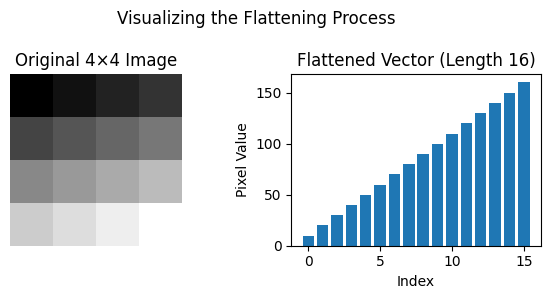

In [10]:
# Simulate a grayscale 4 x 4 image (1 Channel)
image = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120],
    [130, 140, 150, 160]
])

# Flatten it
flattened = image.flatten()

# Plot original and flattened
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original 4×4 Image")
axs[0].axis('off')

axs[1].bar(np.arange(len(flattened)), flattened)
axs[1].set_title("Flattened Vector (Length 16)")
axs[1].set_xlabel("Index")
axs[1].set_ylabel("Pixel Value")

plt.suptitle("Visualizing the Flattening Process")
plt.tight_layout()
plt.show()

In [12]:
# Fetch one sample
image, label = train_dataset[0]
print(f"Original shape: {image.shape}") 

# Flatten the image
flattened = image.view(-1)
print(f"Flattend shape: {flattened.shape}")

Original shape: torch.Size([3, 32, 32])
Flattend shape: torch.Size([3072])


In [13]:
import torchvision.transforms as transforms
# New transform: ToTensor + Flatten

transform = transforms.Compose([
    transforms.ToTensor(),                     # [3, 32, 32], scaled to [0, 1]
    transforms.Lambda(lambda x: x.view(-1))    # Flatten to [3072]
])

In [15]:
from torchvision.datasets import CIFAR10

# Reload with new transform
train_dataset = CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = CIFAR10(root='./data', train=False, transform=transform, download=True)

In [17]:
# Set Seed for reproducibility
torch.manual_seed(42)

# Define batch size (The number of images to feed into the model per time)
batch_size = 64

# Optionally, split train dataset into train + validation
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

# Wrap in DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check sizes
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 704
Validation batches: 79
Test batches: 157


In [18]:
# Check the shape of an image and label in the first batch
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")    # should be [batch_size, 3072]
    print(f"Labels shape: {labels.shape}")   # should be [batch_size]
    break   #just check the first batch

Batch shape: torch.Size([64, 3072])
Labels shape: torch.Size([64])


In [20]:
# Define the MLP class
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    
# Instantiate the model
mlp_model = SimpleMLP()

# Print Model Summary
print(mlp_model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [23]:
import torch.optim as optim

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Tracking 
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # No need to flatten here - already done in transform
        # images = images.view(images.size(0), -1)  # would be needed if not pre-flattened

        # Forward Pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backpropagation and Optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate stats
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # Epoch summary
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss:{epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")



Epoch [1/10] - Loss:1.7215 | Accuracy: 0.3825
Epoch [2/10] - Loss:1.6608 | Accuracy: 0.4067
Epoch [3/10] - Loss:1.6232 | Accuracy: 0.4224
Epoch [4/10] - Loss:1.5920 | Accuracy: 0.4342
Epoch [5/10] - Loss:1.5686 | Accuracy: 0.4418
Epoch [6/10] - Loss:1.5463 | Accuracy: 0.4487
Epoch [7/10] - Loss:1.5338 | Accuracy: 0.4559
Epoch [8/10] - Loss:1.5172 | Accuracy: 0.4592
Epoch [9/10] - Loss:1.5089 | Accuracy: 0.4643
Epoch [10/10] - Loss:1.4913 | Accuracy: 0.4714


Test Accuracy: 0.4639


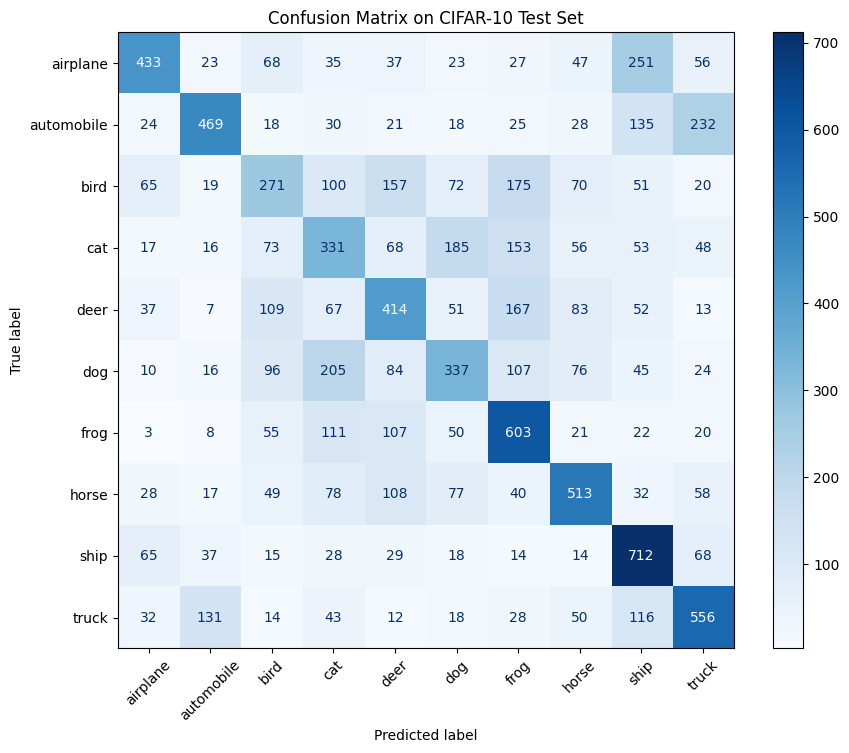

In [28]:
mlp_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        # images = images.view(images.size(0), -1).to(device)
        images = images.to(device)
        labels = labels.to(device)

        outputs = mlp_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#  Compute accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on CIFAR-10 Test Set")
plt.show()

The model correctly identifies certains classes well (e.g automobile, ship and truck), as observed in the high diagonal values. 
Bird, cat and frog have significantly more off-diagonal confusion, especially with each other, which is intuitive because they share visual similarities.
Ship is often misclassified as airplane, likely due to shared backgrounds like sky or water in low-res images. 
Truck frequently gets confused with automobile, which make sense because both of them are vehicles. 

We see that accuracy plateaued at 45 - 46%, and the confusion matrix shows a lot of misclassifications, especially for visually similar categories. Some classes (e.g. ship, truck) did relatively well, while others (like bird, cat) performed poorly. 

This is because with MLPs, there is loss of spatial structure because they flatten images into long 1D vecotrs. Also, there is the presence of too many parameters (3072 x 128 = 393, 216), which leads to high memory usage, overfitting risks and slower convergence during training. 

Finally, MLPs generally have no built-in assumptions about images. They therefore treat all input features as equally important, regardless of the position or locality. 

This is why CNNs are better. 